In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/daily_hotel_data.csv')

In [3]:
df = df[~df.Occupancy_Rate.isna()].copy()

In [4]:
print("--- Data Info ---")
print(df.info())
print("\n--- Sample Data ---")
display(df.head())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 799 entries, 0 to 798
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             799 non-null    object 
 1   Occupancy_Rate   799 non-null    float64
 2   ADR              799 non-null    float64
 3   Is_Weekend       799 non-null    int64  
 4   Local_Event      799 non-null    int64  
 5   Competitor_Rate  799 non-null    float64
 6   Capacity         799 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 49.9+ KB
None

--- Sample Data ---


,Date,Occupancy_Rate,ADR,Is_Weekend,Local_Event,Competitor_Rate,Capacity
0,01-07-2015,0.274262,95.076923,0,0,92.691255,237
1,02-07-2015,0.278481,94.525303,0,0,103.046084,237
2,03-07-2015,0.054852,76.303077,0,0,79.843447,237
3,04-07-2015,0.092827,71.179091,1,0,72.583575,237
4,05-07-2015,0.050633,68.522500,1,0,63.808407,237


In [5]:
df.describe()

,Occupancy_Rate,ADR,Is_Weekend,Local_Event,Competitor_Rate,Capacity
count,799.000000,799.000000,799.000000,799.000000,799.000000,799.0
mean,0.650060,101.133401,0.285357,0.091364,101.085565,237.0
std,0.222751,21.613016,0.451867,0.288307,22.508057,0.0
min,0.008439,0.000000,0.000000,0.000000,0.000000,237.0
25%,0.516034,84.963840,0.000000,0.000000,84.316682,237.0
50%,0.743882,98.836854,0.000000,0.000000,99.130557,237.0
75%,0.819831,117.625575,1.000000,0.000000,118.392411,237.0
max,0.940928,164.231170,1.000000,1.000000,175.913767,237.0


In [7]:
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)

In [8]:
# (Occupancy_Rate = Rooms / Capacity) -> Rooms = Rate * Capacity
df['Occupied_Rooms'] = (df['Occupancy_Rate'] * df['Capacity']).astype(int)

# Metric: Daily Revenue (The "North Star" for your RMS)
df['Revenue'] = df['Occupied_Rooms'] * df['ADR']

# Time Features for Charts
df['Day_Name'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

In [9]:
# Re-order Day_Name for proper sorting in charts
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day_Name'] = pd.Categorical(df['Day_Name'], categories=days_order, ordered=True)

In [10]:
print("--- Data Ready for Analysis ---")
print(df.head())

--- Data Ready for Analysis ---
        Date  Occupancy_Rate        ADR  Is_Weekend  Local_Event  \
0 2015-07-01        0.274262  95.076923           0            0   
1 2015-07-02        0.278481  94.525303           0            0   
2 2015-07-03        0.054852  76.303077           0            0   
3 2015-07-04        0.092827  71.179091           1            0   
4 2015-07-05        0.050633  68.522500           1            0   

   Competitor_Rate  Capacity  Occupied_Rooms      Revenue   Day_Name Month  \
0        92.691255       237              65  6180.000000  Wednesday  July   
1       103.046084       237              65  6144.144697   Thursday  July   
2        79.843447       237              13   991.940000     Friday  July   
3        72.583575       237              21  1494.760909   Saturday  July   
4        63.808407       237              11   753.747500     Sunday  July   

   Year  
0  2015  
1  2015  
2  2015  
3  2015  
4  2015  


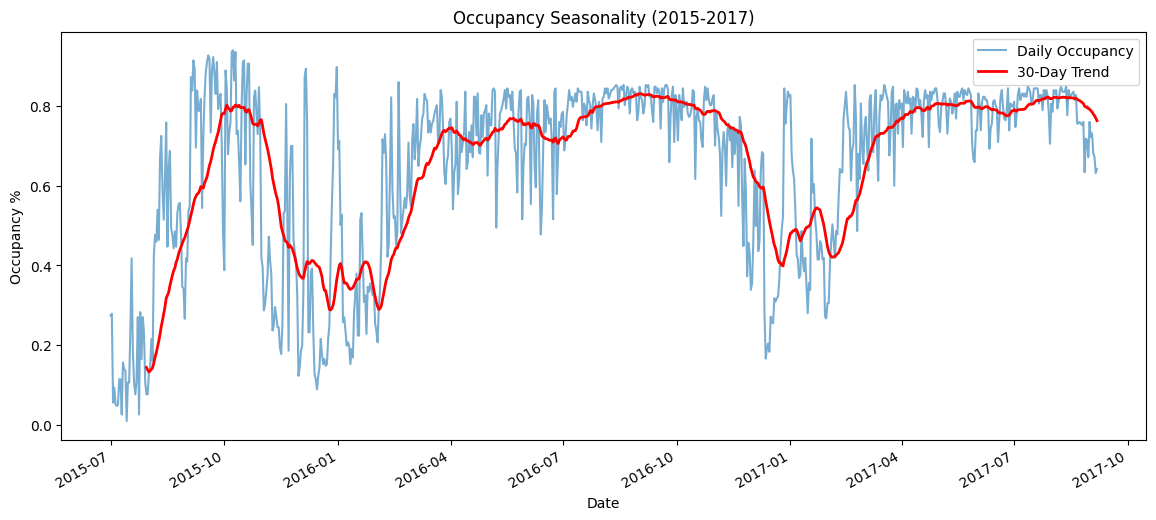

In [11]:
# ==========================================
# VISUALIZATION 1: The "Seasonality" Proof
# ==========================================

plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='Occupancy_Rate', alpha=0.6, label='Daily Occupancy')
# Smooth the line to show the trend clearly
df.set_index('Date')['Occupancy_Rate'].rolling(window=30).mean().plot(color='red', linewidth=2, label='30-Day Trend')
plt.title('Occupancy Seasonality (2015-2017)')
plt.ylabel('Occupancy %')
plt.legend()
plt.show()

#### Occupancy rises in the middle of the year (Summer) and dips at the start/end of the year (Winter). So price elasticity does exist and demand is not random.

C:\Users\Rupesh\AppData\Local\Temp\ipykernel_43352\2947991911.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Local_Event', y='Occupancy_Rate', ax=axes[0], palette='Set2')
C:\Users\Rupesh\AppData\Local\Temp\ipykernel_43352\2947991911.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Normal Day', 'Event/Holiday'])
C:\Users\Rupesh\AppData\Local\Temp\ipykernel_43352\2947991911.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Local_Event', y='ADR', ax=axes[1], palette='Set2')
C:\Users\Rupesh\AppData\Local\Temp\ipykernel_43352\2947991911.py:15: UserWar

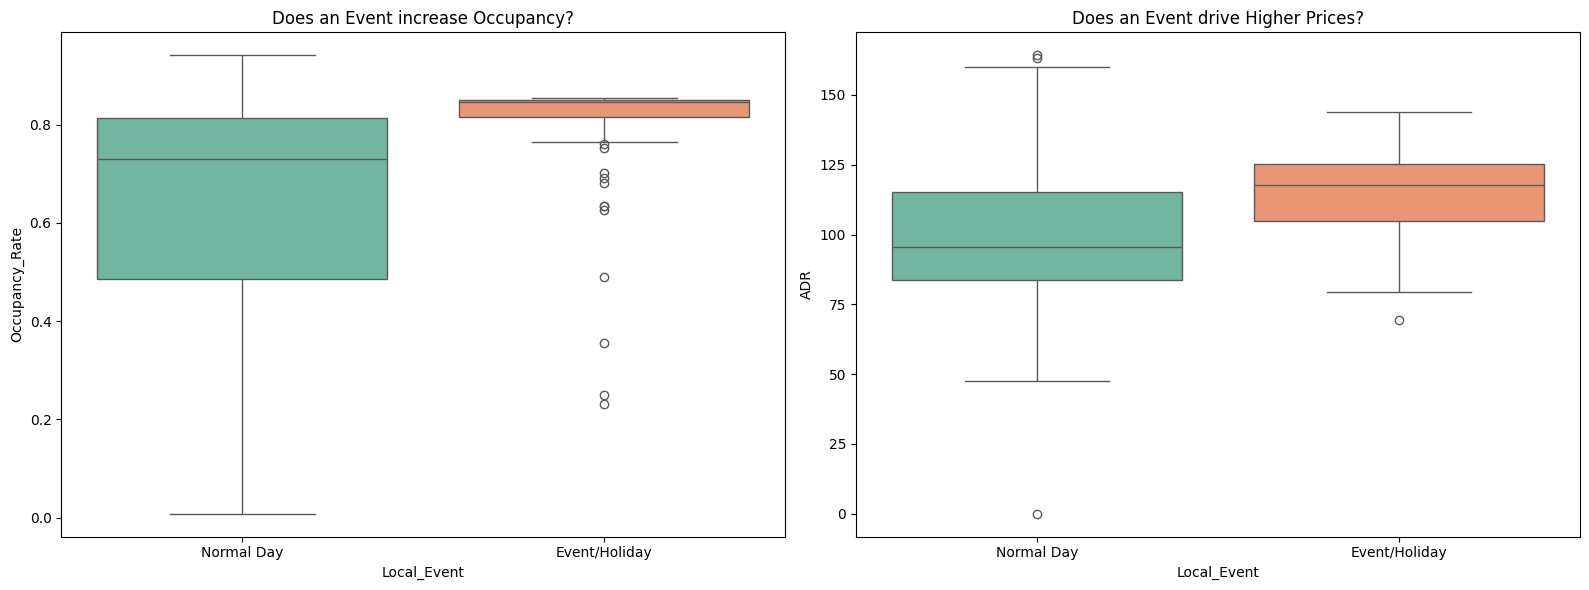

In [12]:
# ==========================================
# VISUALIZATION 2: The "Event Impact" Case
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart A: Occupancy during Events
sns.boxplot(data=df, x='Local_Event', y='Occupancy_Rate', ax=axes[0], palette='Set2')
axes[0].set_title('Does an Event increase Occupancy?')
axes[0].set_xticklabels(['Normal Day', 'Event/Holiday'])

# Chart B: ADR (Price) during Events
sns.boxplot(data=df, x='Local_Event', y='ADR', ax=axes[1], palette='Set2')
axes[1].set_title('Does an Event drive Higher Prices?')
axes[1].set_xticklabels(['Normal Day', 'Event/Holiday'])

plt.tight_layout()
plt.show()

#### 1. Left Chart (Occupancy): The "Event/Holiday" box is much higher and tighter (less variance) than the "Normal Day" box.
#### 2. Right Chart (ADR): The median price for Events is higher than for Normal Days.
#### Analysis: When there is a holiday or event, occupacy and revenue goes up

C:\Users\Rupesh\AppData\Local\Temp\ipykernel_42256\3101691338.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Day_Name', y='ADR', estimator='mean', errorbar=None, ax=axes[0], palette='Blues_d')
C:\Users\Rupesh\AppData\Local\Temp\ipykernel_42256\3101691338.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Day_Name', y='Occupancy_Rate', estimator='mean', errorbar=None, ax=axes[1], palette='Greens_d')


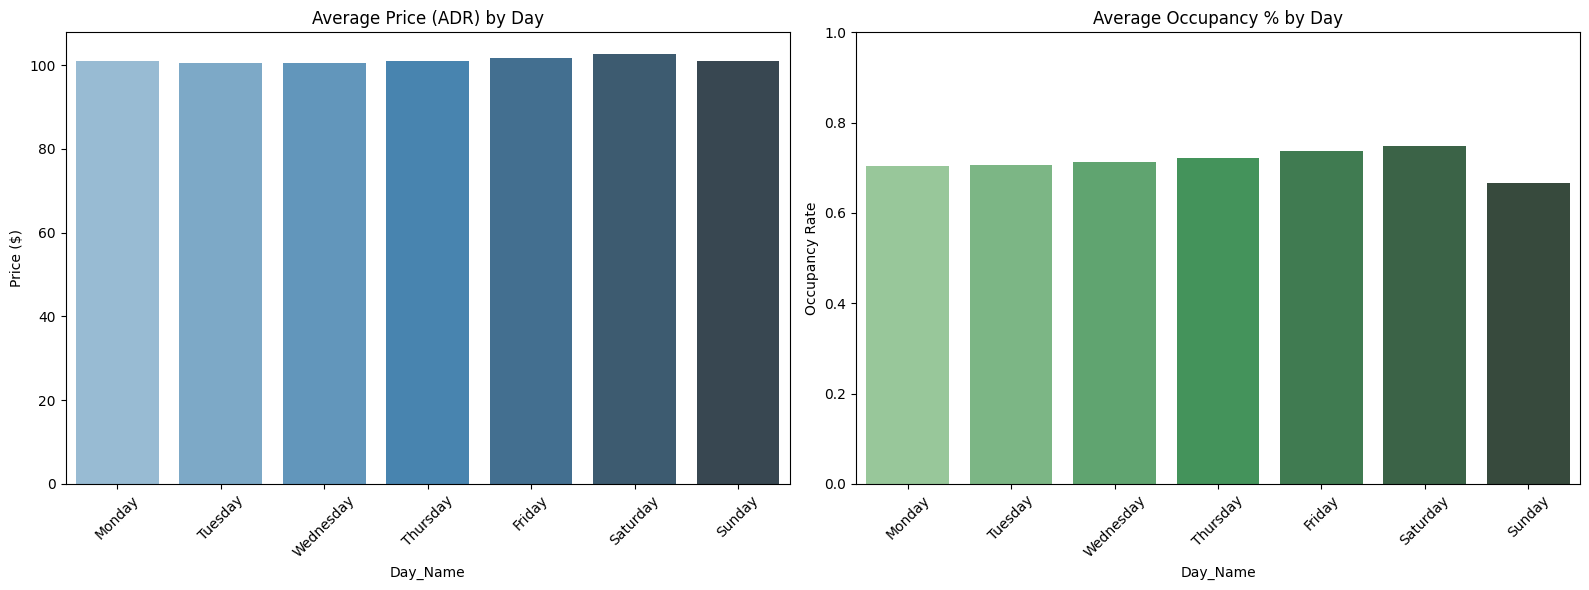

In [39]:
# ==========================================
# VISUALIZATION 3: The "Day of Week" Strategy
# ==========================================
# Now we compare Price (ADR) vs Volume (Occupancy) side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart A: ADR by Day (Price)
sns.barplot(data=df, x='Day_Name', y='ADR', estimator='mean', errorbar=None, ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Price (ADR) by Day')
axes[0].set_ylabel('Price ($)')
axes[0].tick_params(axis='x', rotation=45)

# Chart B: Occupancy by Day (Volume) - [NEW ADDITION]
sns.barplot(data=df, x='Day_Name', y='Occupancy_Rate', estimator='mean', errorbar=None, ax=axes[1], palette='Greens_d')
axes[1].set_title('Average Occupancy % by Day')
axes[1].set_ylabel('Occupancy Rate')
axes[1].set_ylim(0, 1) # Set limit to 100%
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### The Saturday Peak: Both ADR and Occupancy hit their absolute peak on Saturday, showing high demand and a successful yield strategy.
#### The Sunday Slump: Occupancy crashes by -10.84% on Sunday, while ADR only drops by -1.74%. Guests are checking out in large numbers, but the hotel is still trying to hold a high price

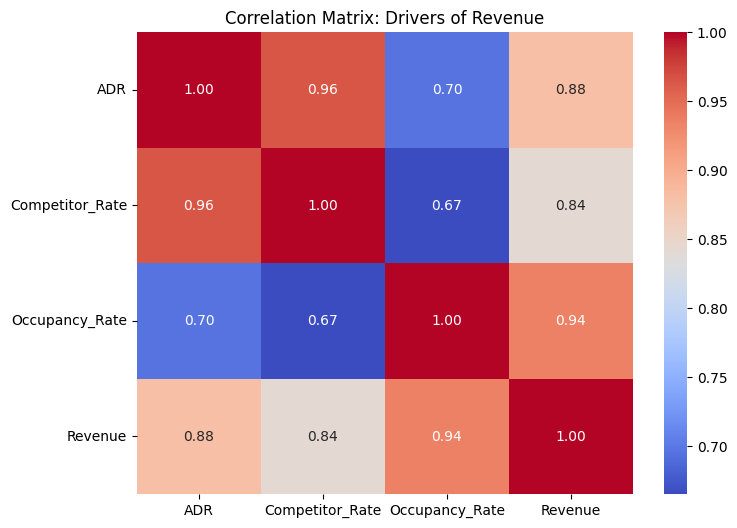

In [38]:
# ==========================================
# VISUALIZATION 4: Competitor Correlation
# ==========================================

plt.figure(figsize=(8, 6))
correlation = df[['ADR', 'Competitor_Rate', 'Occupancy_Rate', 'Revenue']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Drivers of Revenue')
plt.show()

In [43]:
df['Day_of_Week'] = df['Date'].dt.dayofweek
weekday_agg = df.groupby(['Day_of_Week', df['Date'].dt.day_name()]).agg({
    'ADR': 'mean',
    'Occupancy_Rate': 'mean'
}).rename_axis(['Day_ID', 'Day_Name']).reset_index()

# Calculate Day-over-Day Changes
weekday_agg['ADR_Pct_Change'] = weekday_agg['ADR'].pct_change() * 100
weekday_agg['Occupancy_Pct_Change'] = weekday_agg['Occupancy_Rate'].pct_change() * 100

# Final result for display
print(weekday_agg[['Day_Name', 'ADR', 'Occupancy_Rate', 'ADR_Pct_Change', 'Occupancy_Pct_Change']])

    Day_Name         ADR  Occupancy_Rate  ADR_Pct_Change  Occupancy_Pct_Change
0     Monday  100.945084        0.703235             NaN                   NaN
1    Tuesday  100.409465        0.706788       -0.530605              0.505263
2  Wednesday  100.551393        0.712383        0.141349              0.791607
3   Thursday  100.916251        0.721297        0.362858              1.251274
4     Friday  101.570266        0.737878        0.648077              2.298851
5   Saturday  102.666996        0.747761        1.079775              1.339286
6     Sunday  100.879456        0.666741       -1.741105            -10.835025
